In [1]:

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint,TensorBoard
import tensorflow as tf
import joblib

In [5]:
import pandas as pd
X,y=make_classification(n_samples=2000,n_features=20,n_informative=15,random_state=42)
df=pd.DataFrame(X)
df['target']=y
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,target
0,1.546672,2.919781,0.191299,-6.092508,2.069833,2.864001,-0.040455,1.652155,-0.402935,-3.121869,...,0.635586,-5.423878,-0.511763,0.108296,0.296285,0.481769,1.890624,4.138713,1.002354,1
1,1.305370,0.272157,1.381894,-5.866341,3.610104,0.751242,0.051219,-1.875150,3.989834,4.432228,...,0.455291,0.581269,0.154140,-0.771338,-0.381883,-0.095319,-2.428498,-2.097882,1.793455,1
2,-2.124733,-0.142412,1.130832,-3.564792,-0.479976,0.806154,-1.484326,-0.247839,2.493643,0.420206,...,-1.088818,-2.821043,-2.367822,0.278199,-0.704315,2.099515,-0.265496,0.622057,1.655592,0
3,2.598802,-2.744947,-0.086509,-0.407100,0.174895,-1.822290,1.223708,-1.136260,1.374530,-1.129628,...,2.251121,0.264886,0.426528,-2.604662,0.337466,-0.137947,-0.753620,-0.783946,-0.391958,1
4,-0.841869,-3.551324,1.229486,-6.554164,-1.530906,-6.328677,-0.961883,-2.145252,1.610613,-2.187352,...,0.574746,-2.220880,-0.972871,1.554951,-0.930617,0.618355,1.829567,-0.165885,-3.132487,0


In [6]:
X=df.drop('target',axis=1)
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [7]:
model=Sequential([
Dense(128,activation='relu',kernel_regularizer=l2(0.001),input_shape=(20,)),
BatchNormalization(),
Dropout(0.3),
Dense(64,activation='relu',kernel_regularizer=l2(0.001)),
BatchNormalization(),
Dropout(0.3),
Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

/Users/anzarhussain/Documents/Deep Learning Tensorflow/myenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
callbacks=[
EarlyStopping(patience=10,restore_best_weights=True),
ReduceLROnPlateau(patience=5,factor=0.5),
ModelCheckpoint('best_model.keras',save_best_only=True),
TensorBoard(log_dir='logs')
]
history=model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.2,callbacks=callbacks)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9469 - loss: 0.2464 - val_accuracy: 0.9469 - val_loss: 0.2441 - learning_rate: 2.5000e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.9422 - loss: 0.2441 - val_accuracy: 0.9500 - val_loss: 0.2451 - learning_rate: 2.5000e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9516 - loss: 0.2307 - val_accuracy: 0.9469 - val_loss: 0.2433 - learning_rate: 2.5000e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9484 - loss: 0.2385 - val_accuracy: 0.9531 - val_loss: 0.2432 - learning_rate: 2.5000e-04
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - accuracy: 0.9328 - loss: 0.2513 - val_accuracy: 0.9531 - val_loss: 0.2438 - learning_rate: 2.5000e-04
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9500 - loss: 0.2364 - val_accuracy: 0.9500 - val_loss: 0.2415 - learning_rate: 2.5000e-04
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9

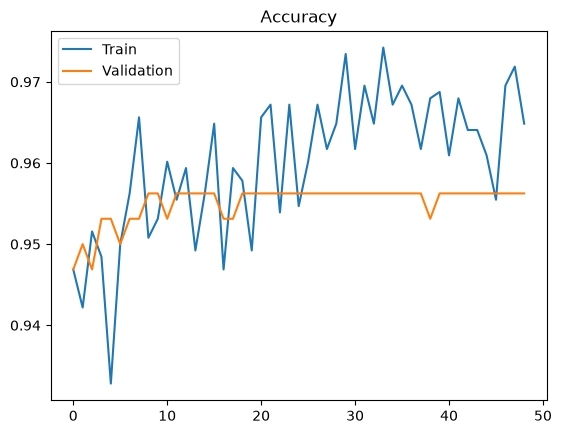

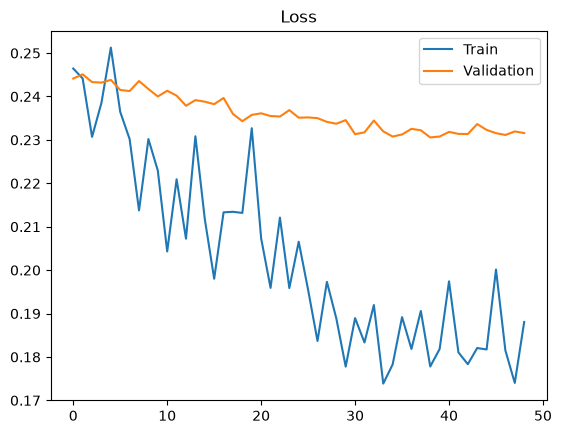

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation']);plt.title('Accuracy');plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation']);plt.title('Loss');plt.show()

In [13]:
import keras_tuner as kt
def build_model(hp):
    model=Sequential()
    model.add(Dense(hp.Int('units',32,256,32),activation=hp.Choice('activation',['relu','tanh','sigmoid'])))
    model.add(Dropout(hp.Float('dropout',0.2,0.5,0.1)))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('lr',[1e-2,1e-3,1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy'])
    return model
tuner=kt.RandomSearch(build_model,objective='val_accuracy',max_trials=5,directory='tuner')
tuner.search(X_train,y_train,epochs=10,validation_split=0.2)


Trial 5 Complete [00h 00m 01s]
val_accuracy: 0.934374988079071

Best val_accuracy So Far: 0.934374988079071
Total elapsed time: 00h 00m 05s


In [14]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

In [15]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

/Users/anzarhussain/Documents/Deep Learning Tensorflow/myenv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(store)


In [16]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 128)              │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
print(
    "Number of neuron in layers:",
    best_hp.get("units")
)

print(
    "activation function used:",
    best_hp.get("activation")
)

print(
    "dropout:",
    best_hp.get("dropout")
)


Number of neuron in layers: 128
activation function used: relu
dropout: 0.2


In [19]:
history=best_model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.2,callbacks=callbacks)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9359 - loss: 0.2033 - val_accuracy: 0.9375 - val_loss: 0.2039 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9414 - loss: 0.1909 - val_accuracy: 0.9375 - val_loss: 0.1944 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9461 - loss: 0.1722 - val_accuracy: 0.9344 - val_loss: 0.1883 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9531 - loss: 0.1630 - val_accuracy: 0.9281 - val_loss: 0.1811 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9609 - loss: 0.1517 - val_accuracy: 0.9344 - val_loss: 0.1762 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.9633 - loss: 0.1469 - val_accuracy: 0.9312 - val_loss: 0.1695 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.9672 - loss: 0.1335 - val